### Семенов Владислав, Stepik-ID 273574954

# **Environmental Sound Classification**

### **Report**

Первоначально выполняем предобработку сигналов в тренировочном датасете:

1) ресэмплируем оригинальный  `sample_rate` в `sample_rate = 16000`;
2) преобразуем стерео в моно;
3) выравниваем длину сигнала до 16000 отсчетов: если сигнал короче, дополняем его нулями до нужной длины;
4) применяем следующие аугментации:
- добавляем случайный шум со случайно выбранным отношением-сигнал шум;
- выполняем училение/ослабление сигнала со случайным параметром `gain_db`;
- добавим случайное линейное затухание сигнала;
- добавим случайное маскирование сигнала.

Все аугментации выполняются независимо с некоторой вероятностью. Вероятность симулируется сэмплированием из равномерного распределения от 0 до 1 с последующим сравнением с порогом.

Архитетура модели:
- первые слои - одномерные сверточные (используем для уменьшения длины последовательности);
- выход со сверточных слоев пропускаем через линейный слой `fc1` для изменения числа скрытых признаков;
- к выходу `fc1` применяем Positional Encoding и пропускаем через стандартный энкодер трансформера;
- выходные данные энкодера агрегируем (усредняем по элементам последовательности) и пропускаем через линейный слой `fc2` для классификации.

Все эксперименты с аритектурой строились в основном вокруг подбора количества слоев и размеров скрытого пространства. Получились такие параметры:
- количество одномерных сверточных слоев и слоев энкодера - 3 и 3;
- число каналов в одномерных свертках - 128, размер фильтра - 3х3, страйд - 2, паддинг - 1;
- число скрытых признаков в слоях энкодера - также 128;
- число голов в multi-head attention - 8.

Наконец, добавил в пайплайн обучения некоторые модификации:
- используем `MultiStepLR`-шедулер с `gamma=0.1`;
- в ходе обучения также увеличиваем порог вероятности аугментации, заданный глобальной переменной `PROB`.

Далее экспериментировал c номерами эпох, на которых применяем шедулер и увеличиваем `PROB`. Итоговые гиперпараметры обучения:
- число эпох - 40;
- шедулер применяем на 35-й эпохе;
- порог вероятности аугментации увеличиваем на каждой 16-й эпохе.

Accuracy на тестовых данных: 0.775.

### **Part 1: Create Dataset**

Скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=c8c5647f-3f78-420a-844c-dd1f43dfee0d
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:07<00:00, 83.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 13.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 5.34MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 4.21MB/s]


Разархивируем zip файл, где содержатся wav файлы датасета.

In [2]:
!unzip /content/sound_classification_dataset.zip

Archive:  /content/sound_classification_dataset.zip
   creating: content/sound_classification_dataset/
  inflating: content/sound_classification_dataset/1-61261-A-44.wav  
  inflating: content/sound_classification_dataset/2-104105-A-19.wav  
  inflating: content/sound_classification_dataset/3-150363-A-38.wav  
  inflating: content/sound_classification_dataset/1-18074-A-6.wav  
  inflating: content/sound_classification_dataset/5-161270-A-33.wav  
  inflating: content/sound_classification_dataset/5-221529-A-39.wav  
  inflating: content/sound_classification_dataset/2-61618-A-46.wav  
  inflating: content/sound_classification_dataset/1-46274-A-18.wav  
  inflating: content/sound_classification_dataset/1-69760-A-16.wav  
  inflating: content/sound_classification_dataset/2-64963-A-15.wav  
  inflating: content/sound_classification_dataset/2-108766-A-9.wav  
  inflating: content/sound_classification_dataset/4-165845-A-45.wav  
  inflating: content/sound_classification_dataset/5-235644-A-30.w

In [3]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [4]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

В тестовом датасете создадим столбец-заглушку.

In [5]:
test_df['category'] = train_df.loc[0, 'category']

Создадим словарь для перевода названий классов в номера меток.

In [6]:
label_to_num = {cat: i for i, cat in enumerate(train_df['category'].unique())}

In [7]:
import torch
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
from torch.utils.data import Dataset
import pandas as pd
import os
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

PROB = 0.7

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, root, df, label_to_num, sr=16000, max_len=16000, do_augmentation=False):
        self.root = root
        self.df = df
        self.do_augmentation = do_augmentation
        if do_augmentation:
            self.dist = torch.distributions.Uniform(0.0, 1.0)
            self.fade = T.Fade(fade_in_len=sr, fade_out_len=sr, fade_shape='linear')
            self.time_mask = T.TimeMasking(1000)
        self.sr = sr
        self.max_len = max_len
        self.label_to_num = label_to_num
        self.num_to_label = {num: label for label, num in label_to_num.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # 1. Get the file path and label
        audio_file_path = f'{self.root}/{self.df.loc[index, 'filename']}'
        label = self.label_to_num[self.df.loc[index, 'category']]

        # 2. LOAD: Load the raw audio file
        signal, sample_rate = torchaudio.load(audio_file_path)

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        signal = signal.squeeze()

        # 5. RETURN: We now have a clean, standardized waveform and its label
        return signal, label

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        signal = F.resample(signal, original_sr, self.sr)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=False)
        return signal

    def _cut_or_pad(self, signal):
        if signal.shape[-1] < self.max_len:
            zeros = torch.zeros(1, self.max_len)
            zeros[:, :len(signal)] = signal
            signal = zeros
        elif signal.shape[-1] > self.max_len:
            signal = signal[:, :self.max_len]
        return signal

    def _augmentation(self, signal):
        if self.dist.sample() > PROB:
            signal = F.add_noise(signal, torch.randn_like(signal), torch.randint(5, 31, (1,)))
        if self.dist.sample() > PROB:
            signal = F.gain(signal, torch.randint(-10, 10, (1,)))
        if self.dist.sample() > PROB:
            signal = self.fade(signal)
        if self.dist.sample() > PROB:
            signal = self.time_mask(signal)
        return signal

In [8]:
root_dir = 'content/sound_classification_dataset'
train_dataset = SimpleAudioDataset(root_dir, train_df, label_to_num, do_augmentation=True)
valid_dataset = SimpleAudioDataset(root_dir, valid_df, label_to_num)

### **Part 2: Building a Model that Learns from Waveforms**

In [9]:
import torch.nn as nn

def get_conv_output_size(input_size, kernel_size, stride, padding):
    return (input_size + 2 * padding - kernel_size) // stride + 1

class SoundClassificatonModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self,
                 input_size=16000,
                 conv_layers=3,
                 out_channels=128,
                 kernel_size=3,
                 stride=2,
                 d_model=128,
                 heads=8,
                 transformer_layers=3,
                 num_classes=5):
        super().__init__()
        conv_list = []
        in_channels = 1
        for _ in range(conv_layers):
            conv_list.append(nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding=kernel_size//2))
            conv_list.append(nn.ReLU())
            conv_list.append(nn.BatchNorm1d(out_channels))
            in_channels = out_channels
            input_size = get_conv_output_size(input_size, kernel_size, stride, kernel_size//2)
        self.conv = nn.Sequential(*conv_list)
        self.fc1 = nn.Linear(out_channels, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)
        self.fc2 = nn.Linear(d_model, num_classes)
        pe = torch.zeros(input_size, d_model)
        position = torch.arange(0, input_size, dtype=torch.float).unsqueeze(1)
        pos_log = torch.log(torch.tensor([10000.0]))
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(pos_log / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = self.conv(x.unsqueeze(1))
        x = self.fc1(x.transpose(1, 2))
        x = self.encoder(x + self.pe)
        x = self.fc2(x.mean(dim=1))
        return x

### **Part 3: Training and Evaluation**

In [10]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


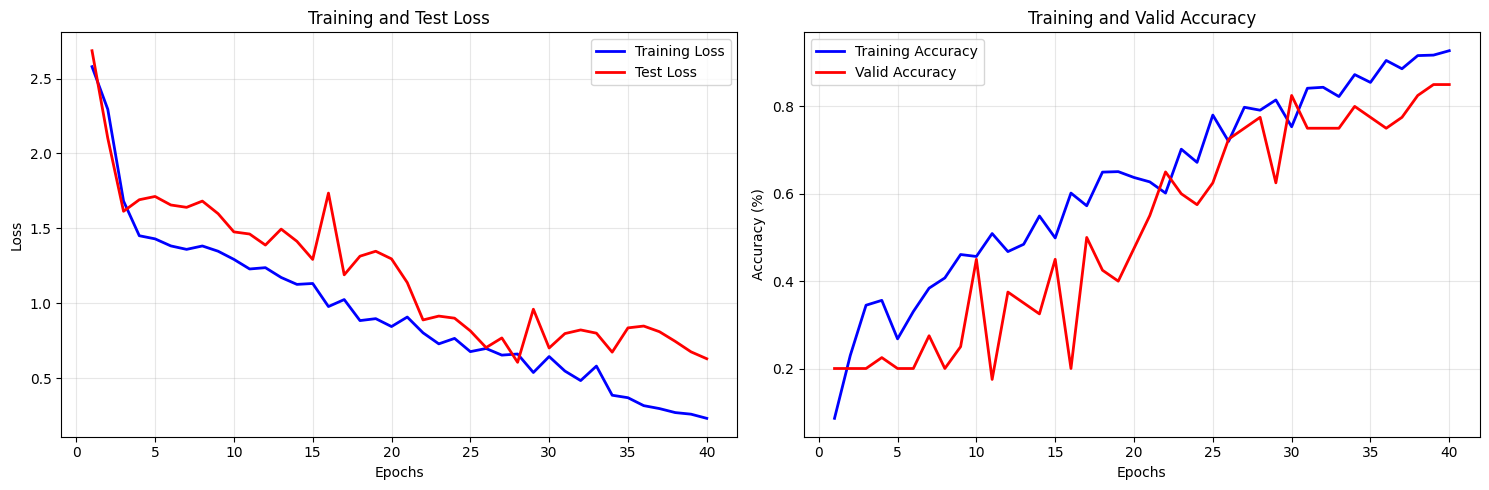

In [11]:
from torch.utils.data import DataLoader
from IPython.display import clear_output


# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(root_dir, train_df, label_to_num, do_augmentation=True)
valid_data = SimpleAudioDataset(root_dir, valid_df, label_to_num)
test_data = SimpleAudioDataset(root_dir, test_df, label_to_num)

bsize = 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=bsize, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=bsize)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=bsize)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 40
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, [35], gamma=0.1)

for epoch in range(n_epochs):

    train_accuracy_sum = 0
    train_loss_sum = 0
    valid_accuracy_sum = 0
    valid_loss_sum = 0

    # Train
    model.train()

    for signals, labels in train_loader:

        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)
        train_accuracy = (predictions.argmax(dim=-1) == labels).sum() / len(labels)

        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        train_accuracy_sum += train_accuracy.item()
        train_loss_sum += train_loss.item()

    scheduler.step()
    if epoch % 16 == 0:
        PROB += 0.1

    # Evaluation
    model.eval()
    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)
            valid_accuracy = (predictions.argmax(dim=-1) == labels).sum() / len(labels)

            valid_accuracy_sum += valid_accuracy.item()
            valid_loss_sum += valid_loss.item()

    # Calculate average test loss and accuracy for this epoch
    epoch_train_loss = train_loss_sum / len(train_loader)
    epoch_train_acc = train_accuracy_sum / len(train_loader)

    epoch_valid_loss = valid_loss_sum / len(valid_loader)
    epoch_valid_acc = valid_accuracy_sum / len(valid_loader)

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

In [12]:
print("Train Accuracy = ", train_accuracies[-1])
print("Valid Accuracy = ", valid_accuracies[-1])

Train Accuracy =  0.9274553656578064
Valid Accuracy =  0.8500000238418579


### **Part 4. Test Demo for ESC-50**

Код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!


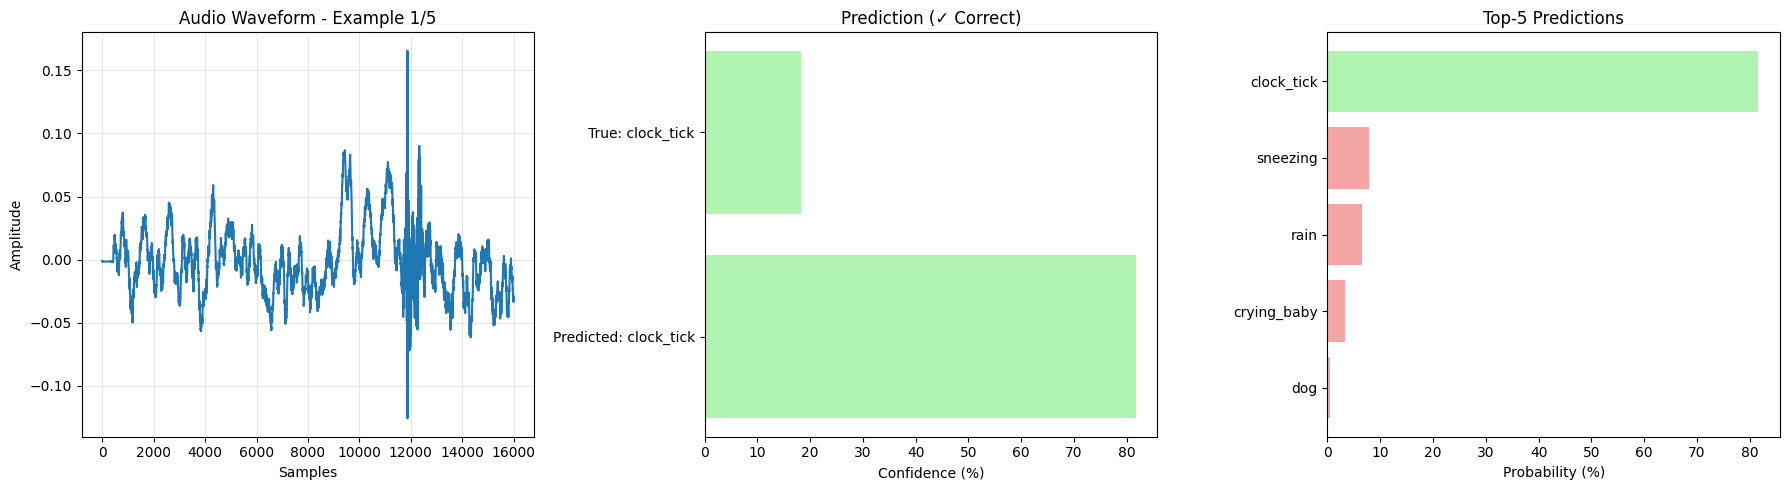

Playing: clock_tick


Prediction: clock_tick (81.65%)
True label: clock_tick
Correct: True


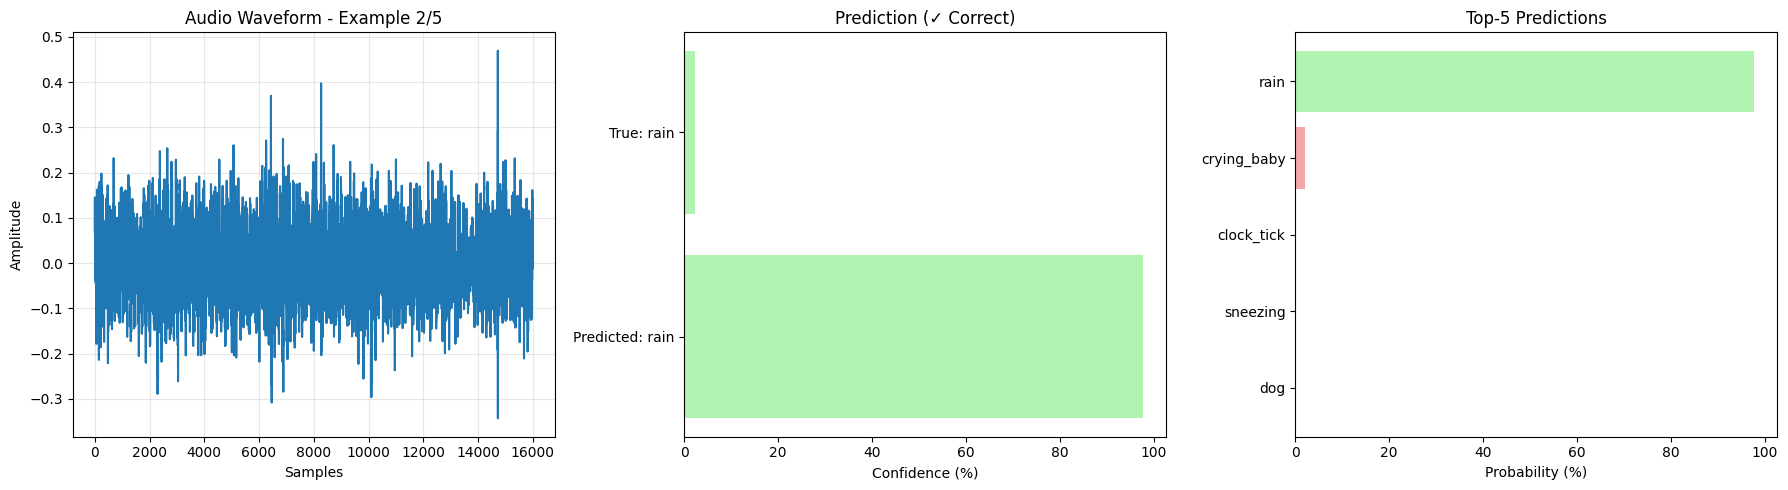

Playing: rain


Prediction: rain (97.67%)
True label: rain
Correct: True


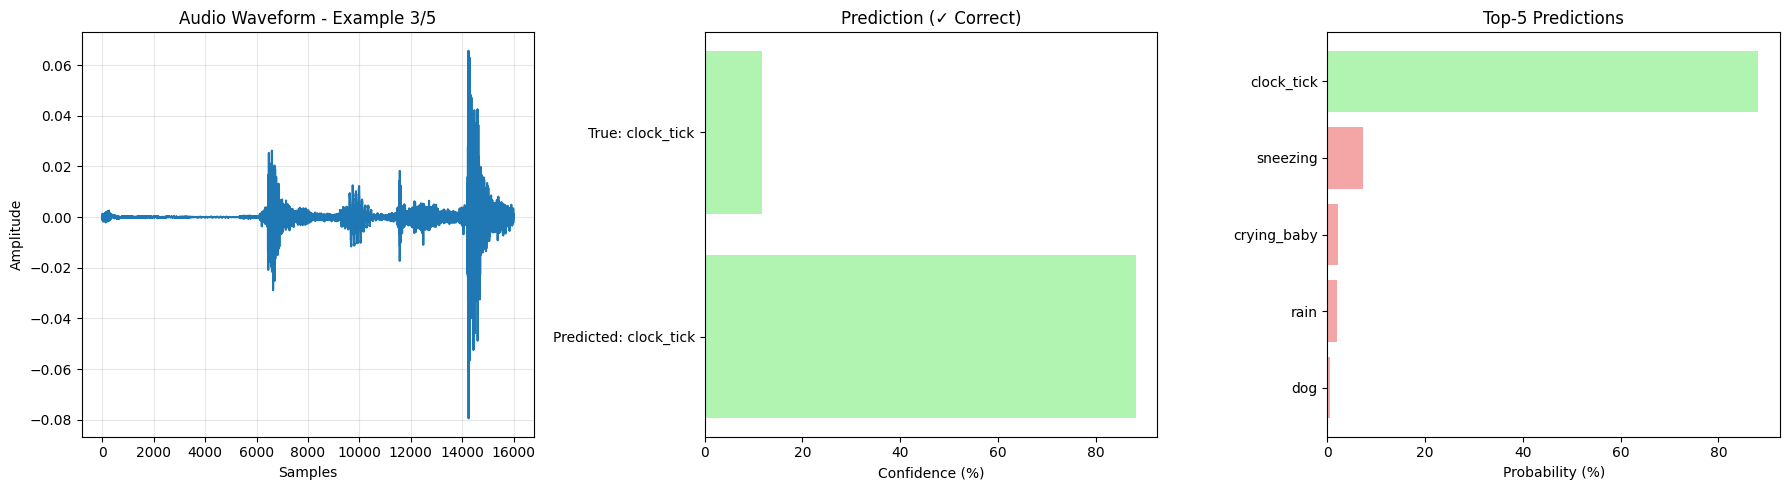

Playing: clock_tick


Prediction: clock_tick (88.17%)
True label: clock_tick
Correct: True


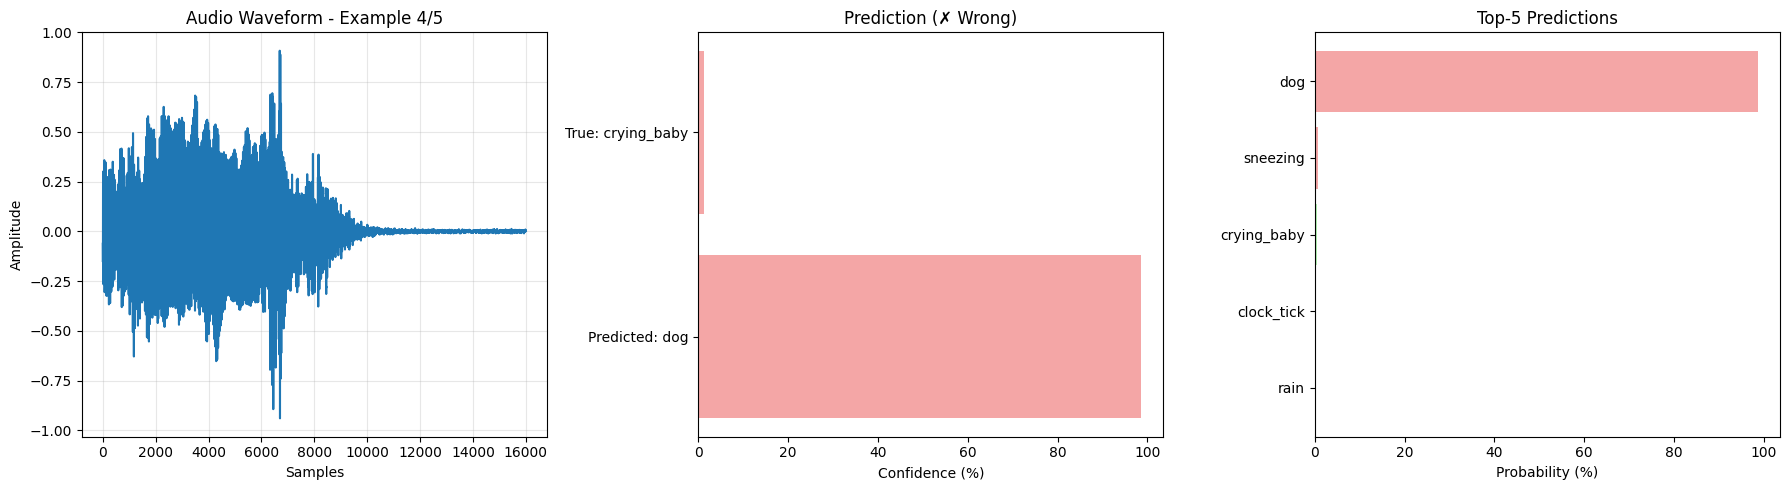

Playing: crying_baby


Prediction: dog (98.63%)
True label: crying_baby
Correct: False


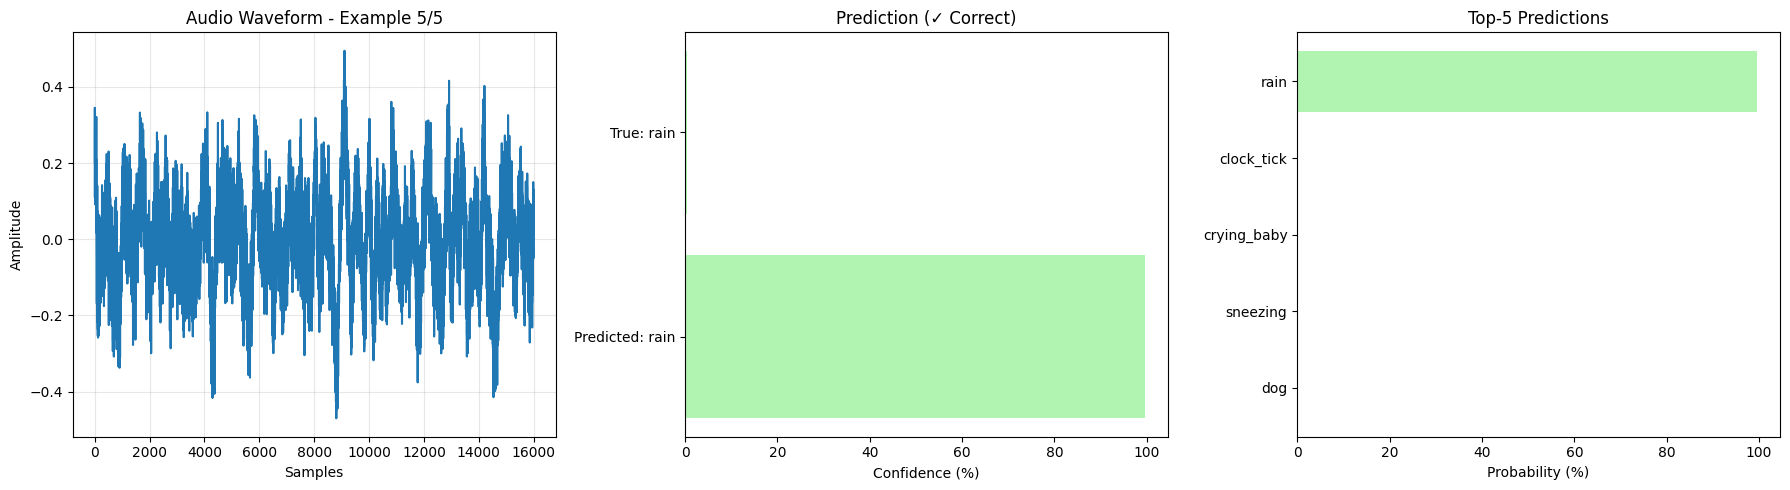

Playing: rain


Prediction: rain (99.56%)
True label: rain
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 34/40
Accuracy: 85.00%


In [13]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.num_to_label
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

In [14]:
y_test_pred = None
for signals, labels in test_loader:
    signals = signals.to(device)
    if y_test_pred is None:
        y_test_pred = model(signals).argmax(dim=-1).squeeze().detach().cpu().numpy()
    else:
        y_test_pred = np.concatenate((y_test_pred, model(signals).argmax(dim=-1).detach().cpu().numpy()))

In [15]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_pred
submission['category'] = submission['category'].apply(lambda x: test_data.num_to_label[x])
submission.to_csv("/content/submission.csv", index=False)